# LSTM

In [1]:
import os
import numpy as np
import librosa
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
# Function to extract features from audio file
def extract_features(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCCs (Mel-frequency cepstral coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of MFCCs
    
    # Extract Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    
    # Extract Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    
    # Combine features into one vector
    return np.concatenate((mfcc, chroma, mel), axis=0)

Playing Audio:


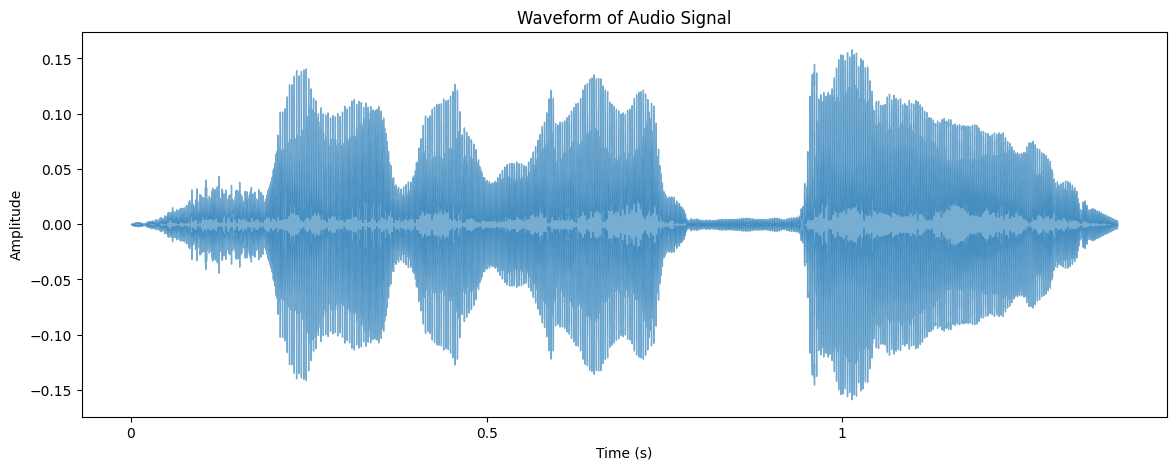

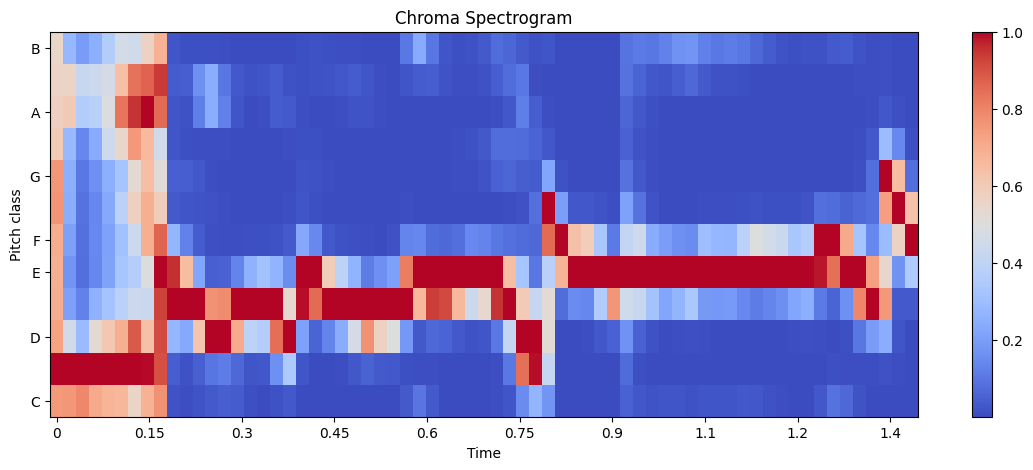

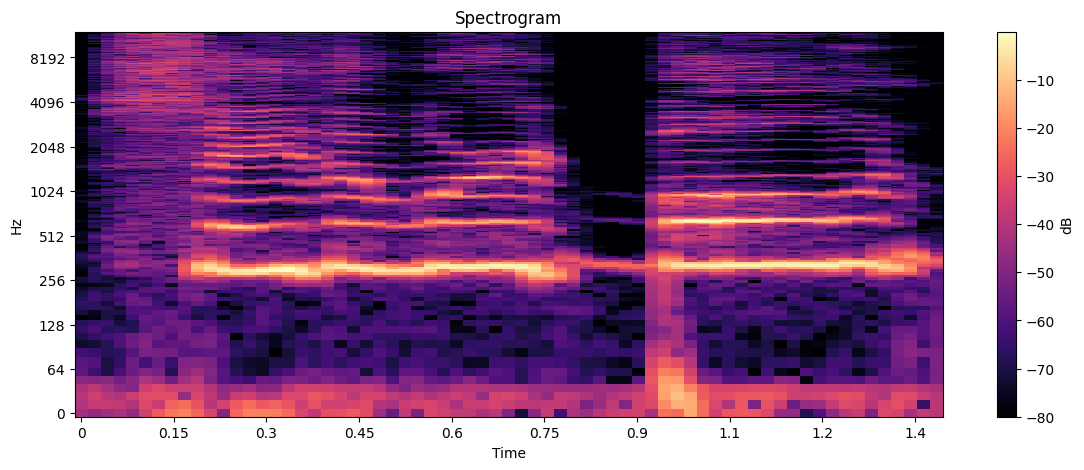

In [8]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# Load the audio file
audio_path = "D:\PYTHON\SPEECH\Tess\OAF_Fear\OAF_bone_fear.wav"  # Change this to your file path
y, sr = librosa.load(audio_path, sr=None)

# Play the audio file
print("Playing Audio:")
ipd.display(ipd.Audio(y, rate=sr))

# Plot Waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Compute and Plot Chroma Spectrogram
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
plt.figure(figsize=(14, 5))
librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma", cmap="coolwarm")
plt.title("Chroma Spectrogram")
plt.colorbar()
plt.show()

# General Data Visualization - Spectrogram
D = np.abs(librosa.stft(y))
plt.figure(figsize=(14, 5))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), sr=sr, x_axis="time", y_axis="log", cmap="magma")
plt.title("Spectrogram")
plt.colorbar(label="dB")
plt.show()


In [9]:
# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    
    # Map of emotions
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_angry': 3, 'OAF_disgust': 4, 'OAF_happy': 5, 'OAF_neutral': 6,
        'YAF_angry': 7, 'YAF_disgust': 8, 'YAF_fear': 9, 'YAF_happy': 10,
        'YAF_neutral': 11, 'YAF_pleasant_surprised': 12, 'YAF_sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)


In [10]:
# Set the path to the dataset
data_path = "D://PYTHON//SPEECH//Tess"
X, y = load_data(data_path) 

# Preprocess labels (one-hot encoding)
y = to_categorical(y, num_classes=14)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape data for LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


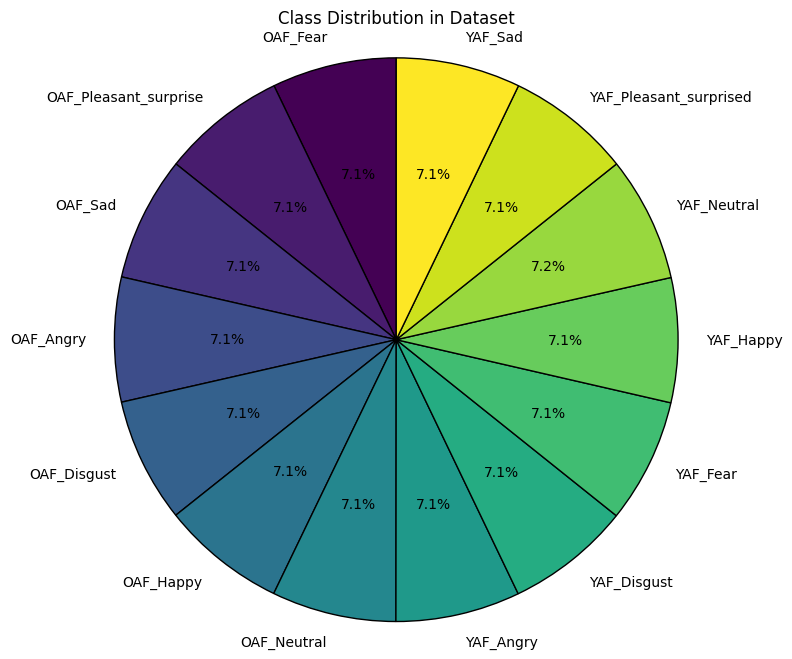

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels back to class indices
class_labels = np.argmax(y, axis=1)

# Count occurrences of each class
unique_classes, counts = np.unique(class_labels, return_counts=True)

# Define class names (Modify based on your dataset)
class_names = [
    "OAF_Fear", "OAF_Pleasant_surprise", "OAF_Sad", "OAF_Angry", "OAF_Disgust", "OAF_Happy", "OAF_Neutral",
    "YAF_Angry", "YAF_Disgust", "YAF_Fear", "YAF_Happy", "YAF_Neutral", "YAF_Pleasant_surprised", "YAF_Sad"
]

# Ensure class_names matches unique_classes
class_names = [class_names[i] for i in unique_classes]

# Get colors from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=colors, wedgeprops={"edgecolor": "black"})
plt.title("Class Distribution in Dataset")
plt.axis("equal")  # Ensures the pie chart is circular
plt.show()


In [15]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(14, activation='softmax'))  # 14 emotion classes
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 128)                 │         144,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 153,550 (599.80 KB)

 Trainable params: 153,550 (599.80 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and store the history
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2436 - loss: 2.4055 - val_accuracy: 0.6364 - val_loss: 1.4186
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6717 - loss: 1.2147 - val_accuracy: 0.8877 - val_loss: 0.6456
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8548 - loss: 0.5775 - val_accuracy: 0.9216 - val_loss: 0.3614
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.3574 - val_accuracy: 0.9180 - val_loss: 0.2624
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9347 - loss: 0.2458 - val_accuracy: 0.9590 - val_loss: 0.1847
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9472 - loss: 0.1961 - val_accuracy: 0.9554 - val_loss: 0.1652
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9598 - loss: 0.1527 - val_accuracy: 0.9661 - val_loss: 0.1317
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9643 - loss: 0.1420 - val_accuracy: 0.9572 - val_loss:

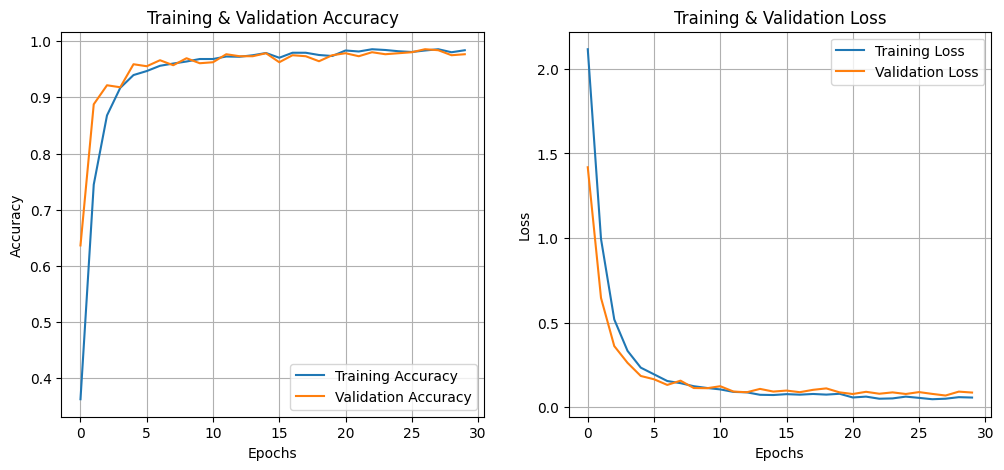

In [17]:
# Function to plot training & validation accuracy and loss
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Call the function to plot accuracy and loss graphs
plot_training_history(history)


In [18]:
# Function to predict emotion for a new audio file
def predict_emotion(file_path):
    # Extract features from the audio file
    features = extract_features(file_path)
    features = features.reshape(1, 1, features.shape[0])  # Reshape to fit LSTM input
    
    # Predict the emotion
    prediction = model.predict(features)
    
    # Map prediction to emotion
    emotion_dict_reverse = {
        0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
        4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
        8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
        12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
    }
    
    predicted_class = np.argmax(prediction)
    return emotion_dict_reverse[predicted_class]

# Example prediction
file_path = "D:\PYTHON\SPEECH\Tess\OAF_Fear\OAF_burn_fear.wav"
predicted_emotion = predict_emotion(file_path)
print(f'Predicted emotion: {predicted_emotion}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
Predicted emotion: OAF_Fear


In [19]:
model.save("Lstm.h5")

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


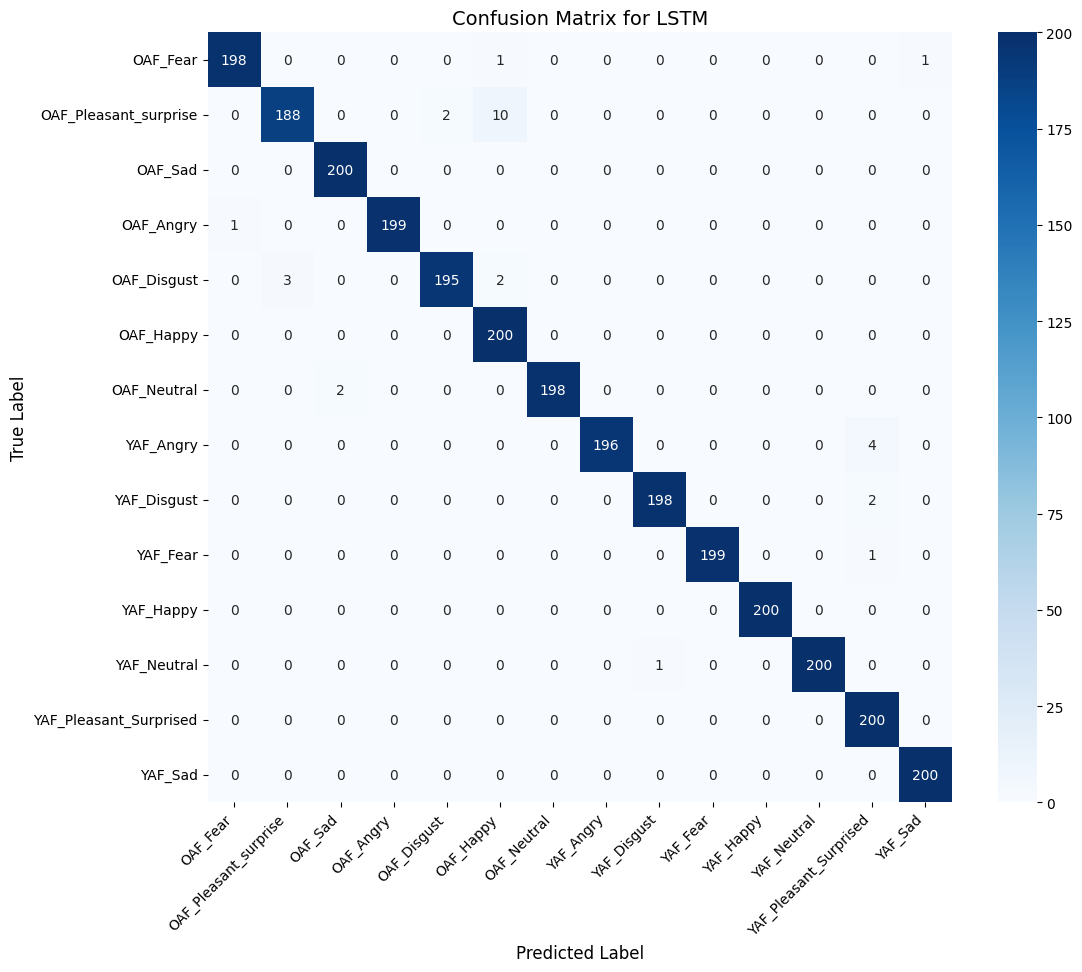

In [21]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

# Function to extract features from audio file
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    return np.concatenate((mfcc, chroma, mel), axis=0)

# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_Angry': 3, 'OAF_Disgust': 4, 'OAF_Happy': 5, 'OAF_Neutral': 6,
        'YAF_Angry': 7, 'YAF_Disgust': 8, 'YAF_Fear': 9, 'YAF_Happy': 10,
        'YAF_Neutral': 11, 'YAF_Pleasant_Surprised': 12, 'YAF_Sad': 13
    }

    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])

    return np.array(features), np.array(labels)

# Function to plot confusion matrix with improved readability
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))  # Increase figure size
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title("Confusion Matrix for LSTM", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate labels
    plt.yticks(rotation=0, fontsize=10)
    plt.show()

# Set the path to the test folder of your dataset
test_data_path = r"D:\PYTHON\SPEECH\Tess\Test"
X_test, y_test = load_data(test_data_path)

# Preprocess labels (one-hot encoding)
y_test = to_categorical(y_test, num_classes=14)

# Reshape data for LSTM (samples, time steps, features)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Load the trained model
model = load_model('LSTM.h5')

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names (updated to your emotion_dict keys)
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_Angry', 'OAF_Disgust', 'OAF_Happy',
    'OAF_Neutral', 'YAF_Angry', 'YAF_Disgust', 'YAF_Fear', 'YAF_Happy', 'YAF_Neutral',
    'YAF_Pleasant_Surprised', 'YAF_Sad'
]

# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)


In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from keras.models import load_model  

# Define class names
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral',
    'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad'
]

# Load trained model
model = load_model('Lstm.h5')

# Predict using the trained model
y_pred = model.predict(X_test)

# Convert predictions and true labels to class indices
y_pred = np.argmax(y_pred, axis=1)  # Converts softmax outputs to class indices
y_test = np.argmax(y_test, axis=1)  # Converts one-hot labels to class indices

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

# Compute precision, recall, and F1-score for each class
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Compute macro-average scores
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.4f}")

# Print per-class metrics
for i, class_name in enumerate(class_names):
    print(f"\nMetrics for {class_name}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1 score: {f1[i]:.4f}")

# Print overall macro-average metrics
print("\nOverall (macro average) metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 score (Macro): {f1_macro:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9893

Metrics for OAF_Fear:
Precision: 0.9950
Recall: 0.9900
F1 score: 0.9925

Metrics for OAF_Pleasant_surprise:
Precision: 0.9843
Recall: 0.9400
F1 score: 0.9616

Metrics for OAF_Sad:
Precision: 0.9901
Recall: 1.0000
F1 score: 0.9950

Metrics for OAF_angry:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for OAF_disgust:
Precision: 0.9898
Recall: 0.9750
F1 score: 0.9824

Metrics for OAF_happy:
Precision: 0.9390
Recall: 1.0000
F1 score: 0.9685

Metrics for OAF_neutral:
Precision: 1.0000
Recall: 0.9900
F1 score: 0.9950

Metrics for YAF_angry:
Precision: 1.0000
Recall: 0.9800
F1 score: 0.9899

Metrics for YAF_disgust:
Precision: 0.9950
Recall: 0.9900
F1 score: 0.9925

Metrics for YAF_fear:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for YAF_happy:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_neutral:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for YAF_pleasant_surprised:
Pre

# BI-LSTM

In [24]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [25]:
# Function to extract features from audio file
def extract_features(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCCs (Mel-frequency cepstral coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of MFCCs
    
    # Extract Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    
    # Extract Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    
    # Combine features into one vector
    return np.concatenate((mfcc, chroma, mel), axis=0)


Playing Audio:


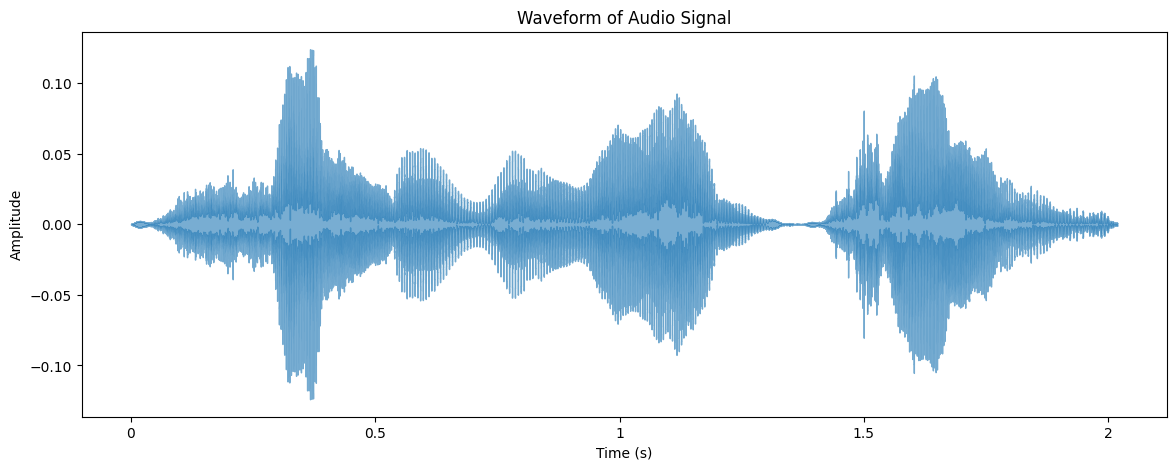

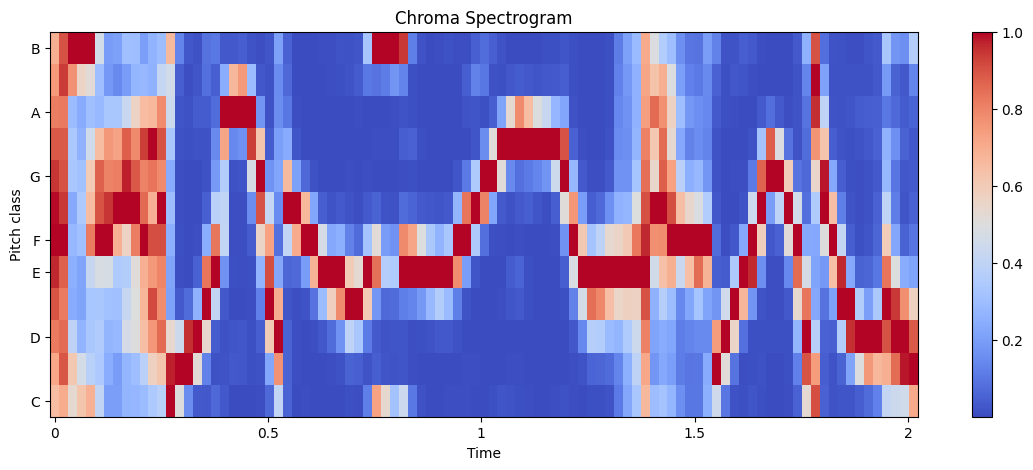

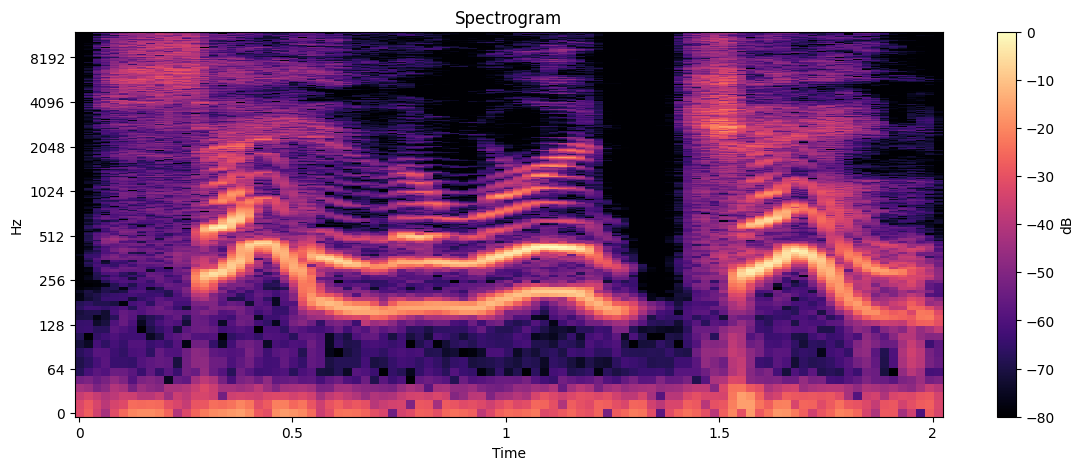

In [26]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# Load the audio file
audio_path = "D:\PYTHON\SPEECH\Tess\OAF_happy\OAF_chain_happy.wav"  # Change this to your file path
y, sr = librosa.load(audio_path, sr=None)

# Play the audio file
print("Playing Audio:")
ipd.display(ipd.Audio(y, rate=sr))

# Plot Waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Compute and Plot Chroma Spectrogram
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
plt.figure(figsize=(14, 5))
librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma", cmap="coolwarm")
plt.title("Chroma Spectrogram")
plt.colorbar()
plt.show()

# General Data Visualization - Spectrogram
D = np.abs(librosa.stft(y))
plt.figure(figsize=(14, 5))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), sr=sr, x_axis="time", y_axis="log", cmap="magma")
plt.title("Spectrogram")
plt.colorbar(label="dB")
plt.show()


In [27]:
# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    
    # Map of emotions
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_angry': 3, 'OAF_disgust': 4, 'OAF_happy': 5, 'OAF_neutral': 6,
        'YAF_angry': 7, 'YAF_disgust': 8, 'YAF_fear': 9, 'YAF_happy': 10,
        'YAF_neutral': 11, 'YAF_pleasant_surprised': 12, 'YAF_sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)



In [28]:
# Set the path to the dataset
data_path =  "D://PYTHON//SPEECH//Tess//"
X, y = load_data(data_path)

# Preprocess labels (one-hot encoding)
y = to_categorical(y, num_classes=14)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape data for LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


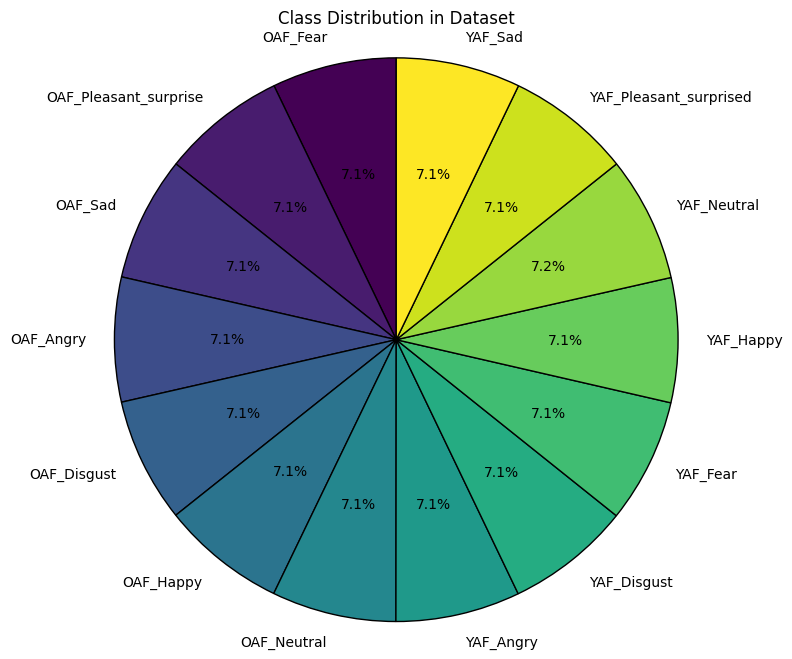

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels back to class indices
class_labels = np.argmax(y, axis=1)

# Count occurrences of each class
unique_classes, counts = np.unique(class_labels, return_counts=True)

# Define class names (Modify based on your dataset)
class_names = [
    "OAF_Fear", "OAF_Pleasant_surprise", "OAF_Sad", "OAF_Angry", "OAF_Disgust", "OAF_Happy", "OAF_Neutral",
    "YAF_Angry", "YAF_Disgust", "YAF_Fear", "YAF_Happy", "YAF_Neutral", "YAF_Pleasant_surprised", "YAF_Sad"
]

# Ensure class_names matches unique_classes
class_names = [class_names[i] for i in unique_classes]

# Get colors from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=colors, wedgeprops={"edgecolor": "black"})
plt.title("Class Distribution in Dataset")
plt.axis("equal")  # Ensures the pie chart is circular
plt.show()


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

# Define the Bidirectional LSTM model
model = Sequential()
model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(14, activation='softmax'))  # 14 emotion classes

# Build the model
model.build(input_shape=(None, X_train.shape[1], X_train.shape[2]))
model.summary()


c:\python39\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         288,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 306,126 (1.17 MB)

 Trainable params: 306,126 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and save the history
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2509 - loss: 2.3774 - val_accuracy: 0.7094 - val_loss: 1.2893
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7285 - loss: 1.0723 - val_accuracy: 0.8645 - val_loss: 0.5802
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8715 - loss: 0.5100 - val_accuracy: 0.9305 - val_loss: 0.3508
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9085 - loss: 0.3266 - val_accuracy: 0.9554 - val_loss: 0.2218
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9421 - loss: 0.2090 - val_accuracy: 0.9572 - val_loss: 0.1695
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9613 - loss: 0.1616 - val_accuracy: 0.9608 - val_loss: 0.1460
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9673 - loss: 0.1371 - val_accuracy: 0.9697 - val_loss: 0.1319
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9664 - loss: 0.1188 - val_accuracy: 0.9608 - val_loss

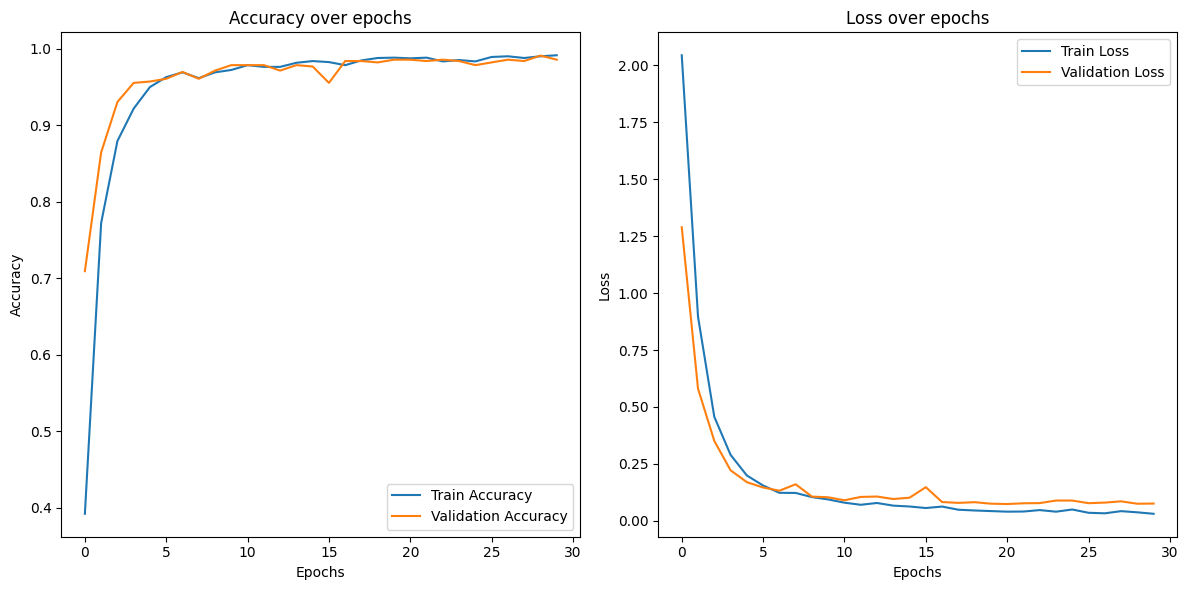

In [33]:
# Plot accuracy and loss graphs
# Accuracy graph
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
# Function to predict emotion for a new audio file
def predict_emotion(file_path):
    # Extract features from the audio file
    features = extract_features(file_path)
    features = features.reshape(1, 1, features.shape[0])  # Reshape to fit LSTM input
    
    # Predict the emotion
    prediction = model.predict(features)
    
    # Map prediction to emotion
    emotion_dict_reverse = {
        0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
        4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
        8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
        12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
    }
    
    predicted_class = np.argmax(prediction)
    return emotion_dict_reverse[predicted_class]

# Example prediction
file_path = "D:\PYTHON\SPEECH\Tess\OAF_Pleasant_surprise\OAF_cause_ps.wav"
predicted_emotion = predict_emotion(file_path)
print(f'Predicted emotion: {predicted_emotion}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Predicted emotion: OAF_Pleasant_surprise


In [35]:
model.save("bi-lstm.h5")

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


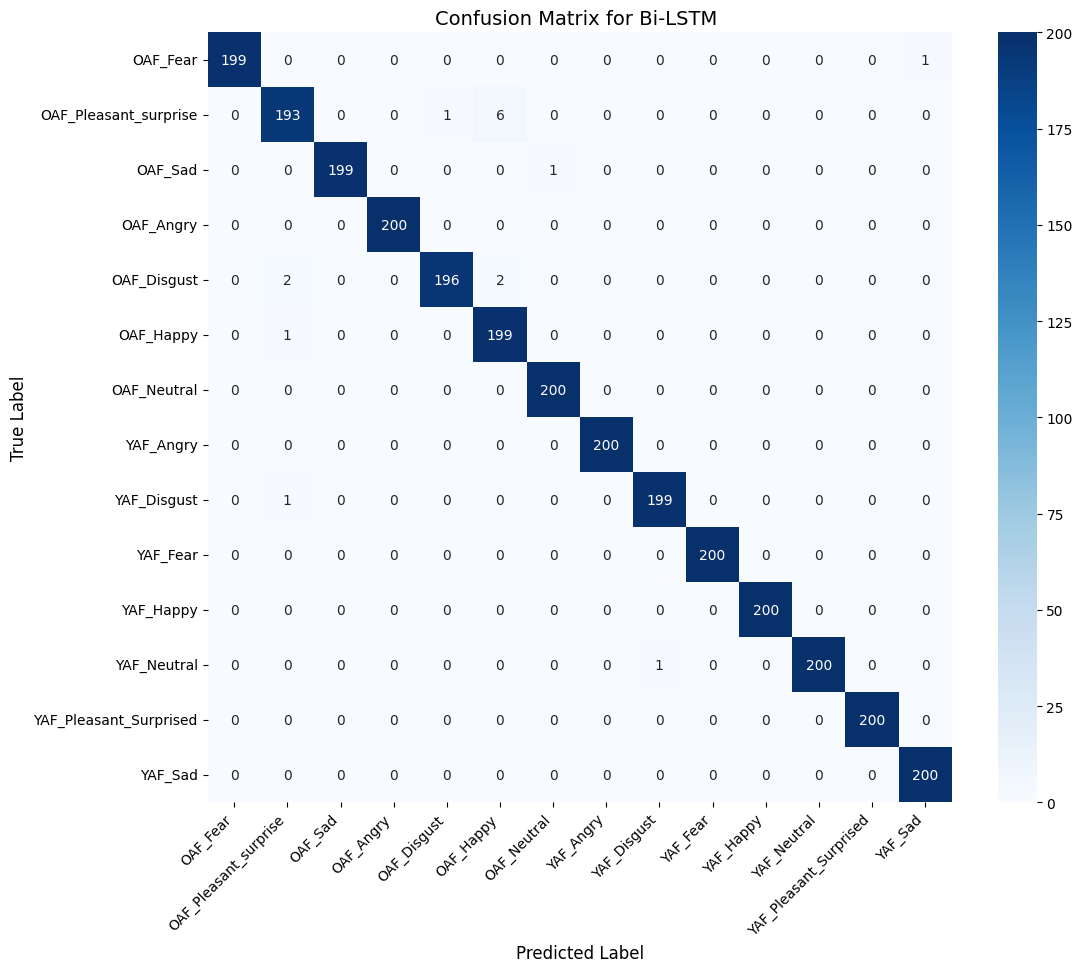

In [36]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

# Function to extract features from audio file
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    return np.concatenate((mfcc, chroma, mel), axis=0)

# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_Angry': 3, 'OAF_Disgust': 4, 'OAF_Happy': 5, 'OAF_Neutral': 6,
        'YAF_Angry': 7, 'YAF_Disgust': 8, 'YAF_Fear': 9, 'YAF_Happy': 10,
        'YAF_Neutral': 11, 'YAF_Pleasant_Surprised': 12, 'YAF_Sad': 13
    }
    
    for emotion, label in emotion_dict.items():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(label)
    
    return np.array(features), np.array(labels)

# Function to plot the confusion matrix with better visualization
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title("Confusion Matrix for Bi-LSTM ", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)  # Rotate labels for clarity
    plt.yticks(rotation=0, fontsize=10)
    plt.show()

# Set the path to the test folder of your dataset
test_data_path = r"D:\PYTHON\SPEECH\Tess\Test"
X_test, y_test = load_data(test_data_path)

# Preprocess labels (one-hot encoding)
y_test = to_categorical(y_test, num_classes=14)

# Reshape data for LSTM (samples, time steps, features)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Load the trained Bi-LSTM model
model = load_model('bi-lstm.h5')

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names (updated to your emotion_dict keys)
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_Angry', 'OAF_Disgust', 'OAF_Happy', 
    'OAF_Neutral', 'YAF_Angry', 'YAF_Disgust', 'YAF_Fear', 'YAF_Happy', 'YAF_Neutral', 
    'YAF_Pleasant_Surprised', 'YAF_Sad'
]

# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)


In [37]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from keras.models import load_model  # Assuming you're using Keras for the model

# Define class names as provided
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral',
    'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad'
]

# Load your trained model (replace 'your_trained_model.h5' with your model file)
model = load_model('bi-lstm.h5')

# Prepare your test data (replace with your actual test data)
# Example: X_test, y_test = your_data_loading_function()

# Predict using the trained model
y_pred = model.predict(X_test)

# If it's a multi-class classification, use np.argmax to get the predicted class index
y_pred = np.argmax(y_pred, axis=1)  # If it's a softmax output for multiclass classification

# If y_test is one-hot encoded, convert it to class indices as well
# This step ensures that both y_test and y_pred are in the same format
y_test = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and f1 score for each class
precision = precision_score(y_test, y_pred, average=None)  # Precision for each class
recall = recall_score(y_test, y_pred, average=None)        # Recall for each class
f1 = f1_score(y_test, y_pred, average=None)                # F1 score for each class

# Calculate overall precision, recall, and F1 score (macro average)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.4f}")

# Print precision, recall, and f1 score for each class
for i, class_name in enumerate(class_names):
    print(f"\nMetrics for {class_name}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1 score: {f1[i]:.4f}")

# Print overall (macro average) precision, recall, and F1 score
print("\nOverall (macro average) metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 score (Macro): {f1_macro:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 0.9943

Metrics for OAF_Fear:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for OAF_Pleasant_surprise:
Precision: 0.9797
Recall: 0.9650
F1 score: 0.9723

Metrics for OAF_Sad:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for OAF_angry:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for OAF_disgust:
Precision: 0.9949
Recall: 0.9800
F1 score: 0.9874

Metrics for OAF_happy:
Precision: 0.9614
Recall: 0.9950
F1 score: 0.9779

Metrics for OAF_neutral:
Precision: 0.9950
Recall: 1.0000
F1 score: 0.9975

Metrics for YAF_angry:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_disgust:
Precision: 0.9950
Recall: 0.9950
F1 score: 0.9950

Metrics for YAF_fear:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_happy:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_neutral:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for YAF_pleasant_surprised:
Pre

# CNN-LSTM

In [56]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix


In [57]:
# Function to extract features from audio file
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCCs (Mel-frequency cepstral coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of MFCCs
    
    # Extract Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    
    # Extract Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    
    # Combine features into one vector
    return np.concatenate((mfcc, chroma, mel), axis=0)


In [58]:
# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    
    # Emotion dictionary mapping
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_angry': 3, 'OAF_disgust': 4, 'OAF_happy': 5, 'OAF_neutral': 6,
        'YAF_angry': 7, 'YAF_disgust': 8, 'YAF_fear': 9, 'YAF_happy': 10,
        'YAF_neutral': 11, 'YAF_pleasant_surprised': 12, 'YAF_sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)


In [60]:
# Set the path to the dataset
data_path = "D://PYTHON//SPEECH//Tess"

# Load data
X, y = load_data(data_path)

# Preprocess labels (one-hot encoding)
y = to_categorical(y, num_classes=14)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape data for CNN-LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


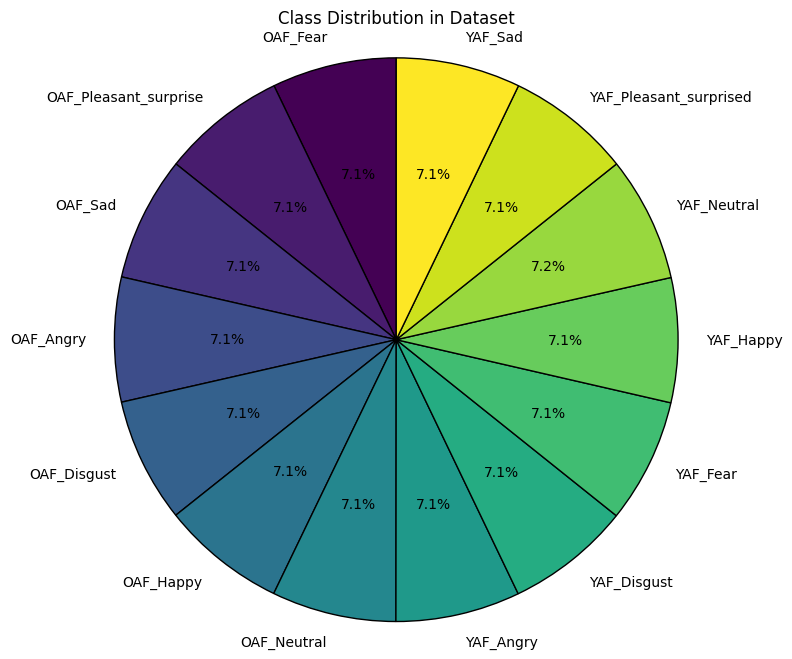

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels back to class indices
class_labels = np.argmax(y, axis=1)

# Count occurrences of each class
unique_classes, counts = np.unique(class_labels, return_counts=True)

# Define class names (Modify based on your dataset)
class_names = [
    "OAF_Fear", "OAF_Pleasant_surprise", "OAF_Sad", "OAF_Angry", "OAF_Disgust", "OAF_Happy", "OAF_Neutral",
    "YAF_Angry", "YAF_Disgust", "YAF_Fear", "YAF_Happy", "YAF_Neutral", "YAF_Pleasant_surprised", "YAF_Sad"
]

# Ensure class_names matches unique_classes
class_names = [class_names[i] for i in unique_classes]

# Get colors from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=colors, wedgeprops={"edgecolor": "black"})
plt.title("Class Distribution in Dataset")
plt.axis("equal")  # Ensures the pie chart is circular
plt.show()


In [62]:
# Define the CNN-LSTM model
model = Sequential()

# CNN layers
model.add(Conv1D(64, 5, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(2))
model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(2))

# LSTM layer
model.add(LSTM(128, return_sequences=False))

# Fully connected layers
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(14, activation='softmax'))  # 14 emotion classes

# Model summary
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 149, 64)             │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ (None, 74, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 70, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ (None, 35, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 182,222 (711.80 KB)

 Trainable params: 182,222 (711.80 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model and store the history
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.1725 - loss: 2.3270 - val_accuracy: 0.3226 - val_loss: 1.6385
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3169 - loss: 1.6654 - val_accuracy: 0.3761 - val_loss: 1.3626
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4233 - loss: 1.3827 - val_accuracy: 0.5508 - val_loss: 1.1071
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5755 - loss: 1.0599 - val_accuracy: 0.6613 - val_loss: 0.7779
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6830 - loss: 0.8109 - val_accuracy: 0.7843 - val_loss: 0.5848
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7477 - loss: 0.6730 - val_accuracy: 0.7701 - val_loss: 0.5656
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8138 - loss: 0.5067 - val_accuracy: 0.8485 - val_loss: 0.4184
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8355 - loss: 0.4293 - val_accuracy: 0.8770 - v

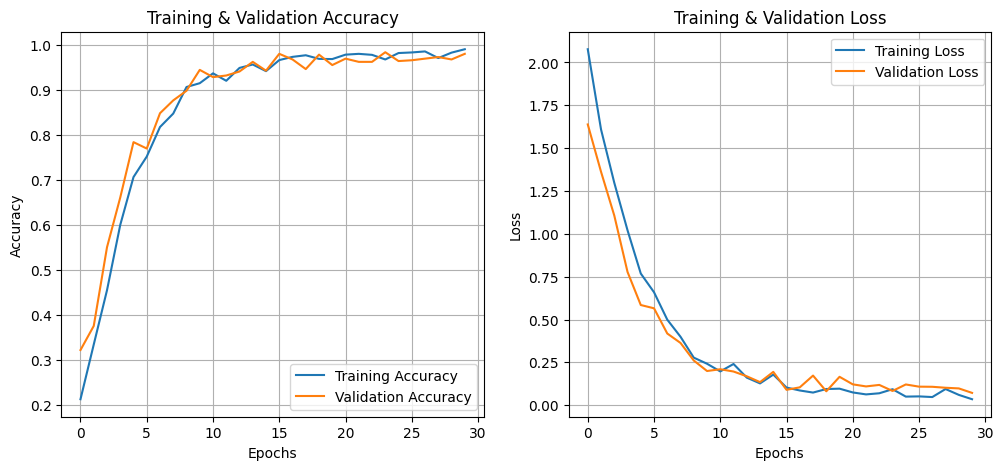

In [64]:
# Function to plot training & validation accuracy and loss
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Call the function to plot accuracy and loss graphs
plot_training_history(history)


In [65]:
model.save("cnn-lstm.h5")

In [68]:
# Function to predict emotion for a new audio file
def predict_emotion(file_path):
    # Extract features from the audio file
    features = extract_features(file_path)
    features = features.reshape(1, features.shape[0], 1)  # Reshape to fit CNN-LSTM input
    
    # Predict the emotion
    prediction = model.predict(features)
    
    # Map prediction to emotion
    emotion_dict_reverse = {
        0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_Angry',
        4: 'OAF_Disgust', 5: 'OAF_Happy', 6: 'OAF_Neutral', 7: 'YAF_Angry',
        8: 'YAF_Disgust', 9: 'YAF_Fear', 10: 'YAF_Happy', 11: 'YAF_Neutral',
        12: 'YAF_Pleasant_Surprised', 13: 'YAF_Sad'
    }
    
    predicted_class = np.argmax(prediction)
    return emotion_dict_reverse[predicted_class]

# Example prediction
file_path = "D:\PYTHON\SPEECH\Tess\OAF_Fear\OAF_burn_fear.wav"
predicted_emotion = predict_emotion(file_path)
print(f'Predicted emotion: {predicted_emotion}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Predicted emotion: OAF_Fear


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


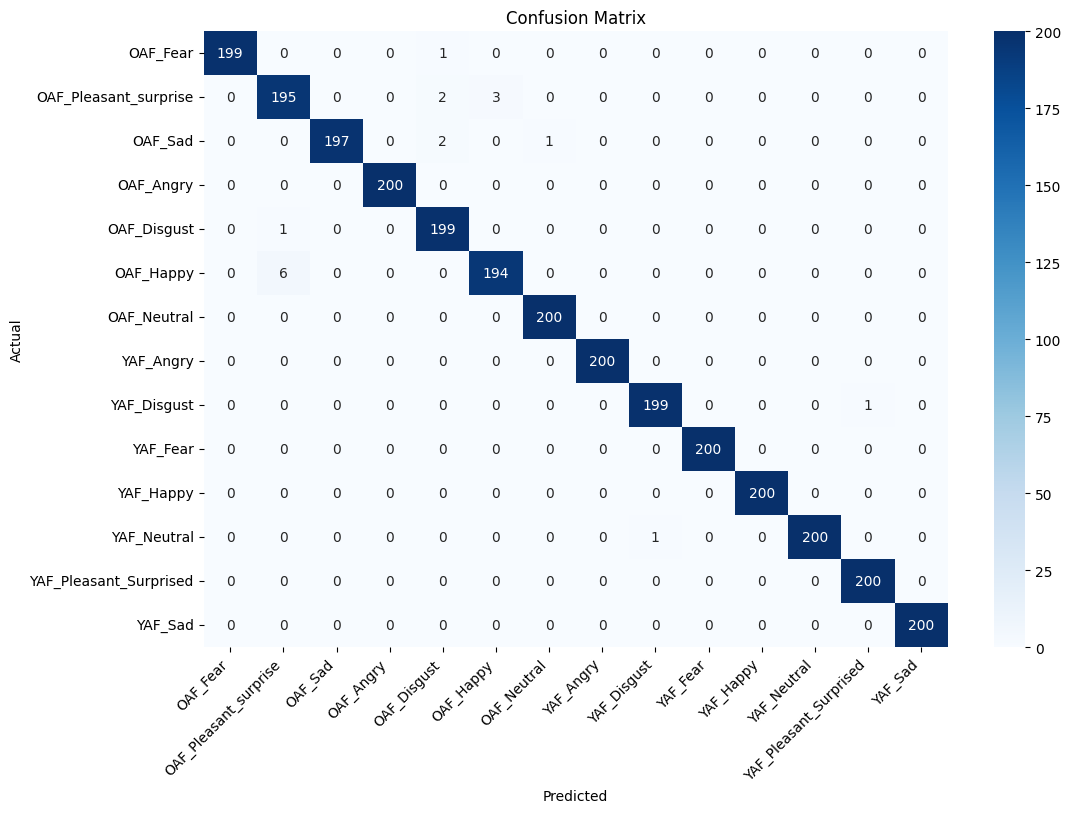

In [76]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

# Function to extract features from audio file
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    return np.concatenate((mfcc, chroma, mel), axis=0)

# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_Angry': 3, 'OAF_Disgust': 4, 'OAF_Happy': 5, 'OAF_Neutral': 6,
        'YAF_Angry': 7, 'YAF_Disgust': 8, 'YAF_Fear': 9, 'YAF_Happy': 10,
        'YAF_Neutral': 11, 'YAF_Pleasant_Surprised': 12, 'YAF_Sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)

# Function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

# Set the path to the test folder of your dataset
test_data_path = r"D:\PYTHON\SPEECH\Tess\Test"
X_test, y_test = load_data(test_data_path)

# Preprocess labels (one-hot encoding)
y_test = to_categorical(y_test, num_classes=14)

# Reshape data for CNN-LSTM (samples, time steps, features)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Load the trained model (if not already in memory)
model = load_model('cnn-lstm.h5')  # Use the correct model path

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names (updated to your emotion_dict keys)
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_Angry', 'OAF_Disgust', 'OAF_Happy', 
    'OAF_Neutral', 'YAF_Angry', 'YAF_Disgust', 'YAF_Fear', 'YAF_Happy', 'YAF_Neutral', 
    'YAF_Pleasant_Surprised', 'YAF_Sad'
]

# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)


In [77]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from keras.models import load_model  # Assuming you're using Keras for the model

# Define class names as provided
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral',
    'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad'
]

# Load your trained model (replace 'your_trained_model.h5' with your model file)
model = load_model('cnn-lstm.h5')

# Prepare your test data (replace with your actual test data)
# Example: X_test, y_test = your_data_loading_function()

# Predict using the trained model
y_pred = model.predict(X_test)

# If it's a multi-class classification, use np.argmax to get the predicted class index
y_pred = np.argmax(y_pred, axis=1)  # If it's a softmax output for multiclass classification

# If y_test is one-hot encoded, convert it to class indices as well
# This step ensures that both y_test and y_pred are in the same format
y_test = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and f1 score for each class
precision = precision_score(y_test, y_pred, average=None)  # Precision for each class
recall = recall_score(y_test, y_pred, average=None)        # Recall for each class
f1 = f1_score(y_test, y_pred, average=None)                # F1 score for each class

# Calculate overall precision, recall, and F1 score (macro average)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.4f}")

# Print precision, recall, and f1 score for each class
for i, class_name in enumerate(class_names):
    print(f"\nMetrics for {class_name}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1 score: {f1[i]:.4f}")

# Print overall (macro average) precision, recall, and F1 score
print("\nOverall (macro average) metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 score (Macro): {f1_macro:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Accuracy: 0.9936

Metrics for OAF_Fear:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for OAF_Pleasant_surprise:
Precision: 0.9653
Recall: 0.9750
F1 score: 0.9701

Metrics for OAF_Sad:
Precision: 1.0000
Recall: 0.9850
F1 score: 0.9924

Metrics for OAF_angry:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for OAF_disgust:
Precision: 0.9755
Recall: 0.9950
F1 score: 0.9851

Metrics for OAF_happy:
Precision: 0.9848
Recall: 0.9700
F1 score: 0.9773

Metrics for OAF_neutral:
Precision: 0.9950
Recall: 1.0000
F1 score: 0.9975

Metrics for YAF_angry:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_disgust:
Precision: 0.9950
Recall: 0.9950
F1 score: 0.9950

Metrics for YAF_fear:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_happy:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for YAF_neutral:
Precision: 1.0000
Recall: 0.9950
F1 score: 0.9975

Metrics for YAF_pleasant_surprised:
Pr

# RNN

In [78]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [79]:

# Function to extract features from audio file
def extract_features(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)
    
    # Extract MFCCs (Mel-frequency cepstral coefficients)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of MFCCs
    
    # Extract Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    
    # Extract Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    
    # Combine features into one vector
    return np.concatenate((mfcc, chroma, mel), axis=0)

Playing Audio:


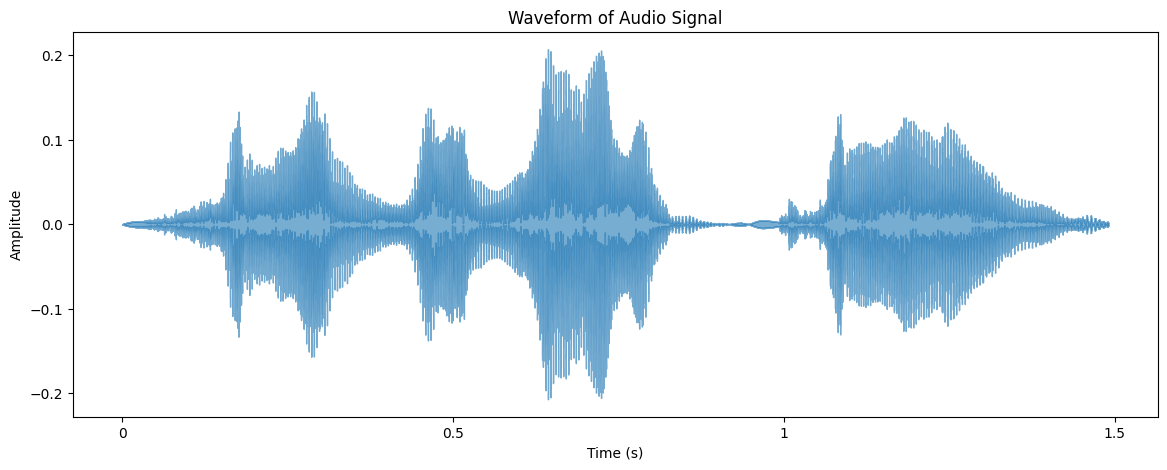

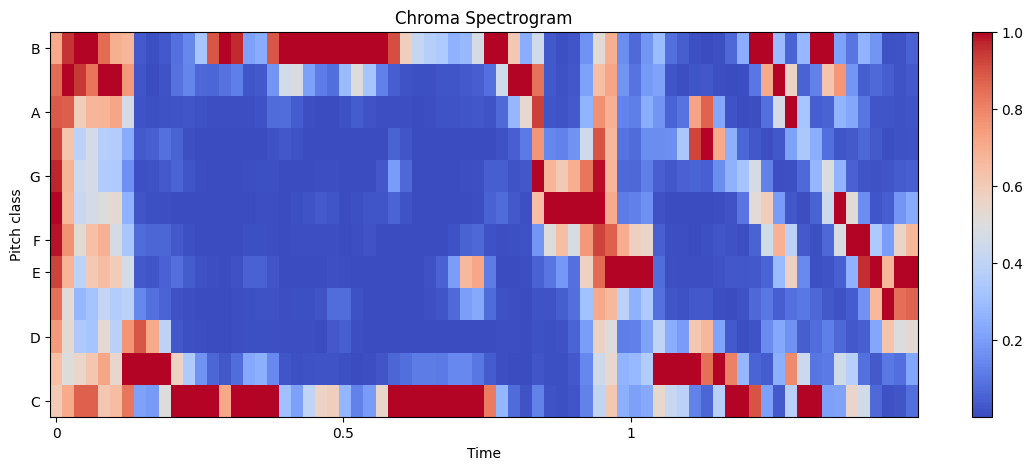

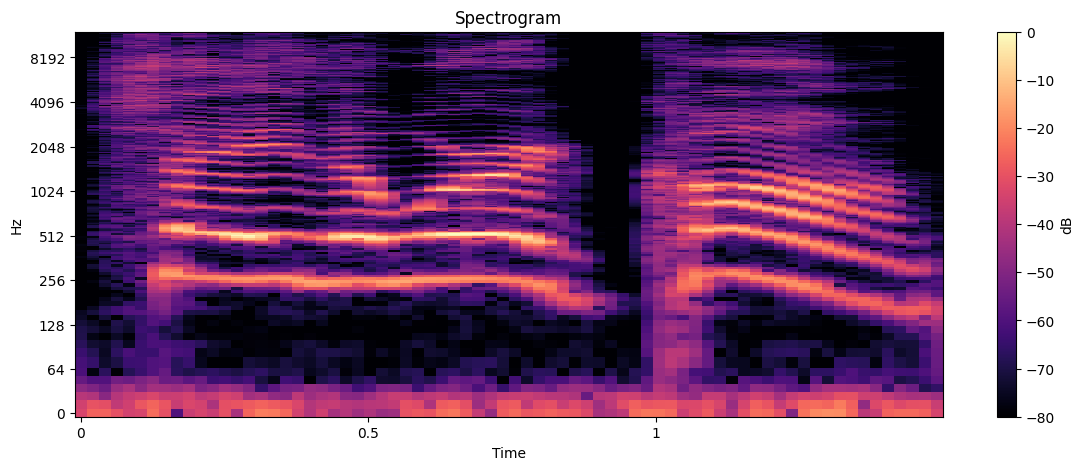

In [80]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# Load the audio file
audio_path =  "D:\PYTHON\SPEECH\Tess\OAF_angry\OAF_calm_angry.wav"  # Change this to your file path
y, sr = librosa.load(audio_path, sr=None)

# Play the audio file
print("Playing Audio:")
ipd.display(ipd.Audio(y, rate=sr))

# Plot Waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Compute and Plot Chroma Spectrogram
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
plt.figure(figsize=(14, 5))
librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma", cmap="coolwarm")
plt.title("Chroma Spectrogram")
plt.colorbar()
plt.show()

# General Data Visualization - Spectrogram
D = np.abs(librosa.stft(y))
plt.figure(figsize=(14, 5))
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), sr=sr, x_axis="time", y_axis="log", cmap="magma")
plt.title("Spectrogram")
plt.colorbar(label="dB")
plt.show()


In [81]:
# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    
    # Map of emotions
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_angry': 3, 'OAF_disgust': 4, 'OAF_happy': 5, 'OAF_neutral': 6,
        'YAF_angry': 7, 'YAF_disgust': 8, 'YAF_fear': 9, 'YAF_happy': 10,
        'YAF_neutral': 11, 'YAF_pleasant_surprised': 12, 'YAF_sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)

In [84]:

# Set the path to the dataset
data_path = "D://PYTHON//SPEECH//Tess//"
X, y = load_data(data_path)

# Preprocess labels (one-hot encoding)
y = to_categorical(y, num_classes=14)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape data for RNN (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


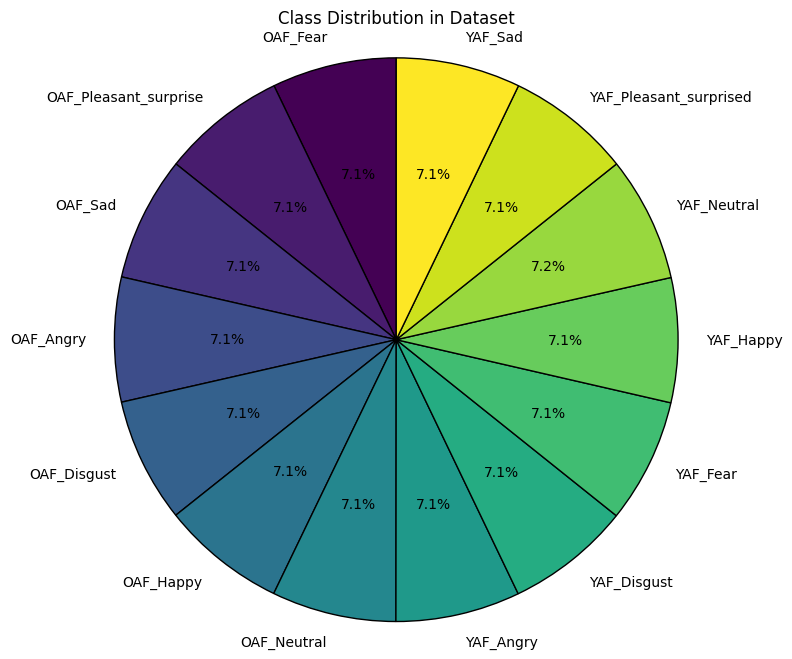

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded labels back to class indices
class_labels = np.argmax(y, axis=1)

# Count occurrences of each class
unique_classes, counts = np.unique(class_labels, return_counts=True)

# Define class names (Modify based on your dataset)
class_names = [
    "OAF_Fear", "OAF_Pleasant_surprise", "OAF_Sad", "OAF_Angry", "OAF_Disgust", "OAF_Happy", "OAF_Neutral",
    "YAF_Angry", "YAF_Disgust", "YAF_Fear", "YAF_Happy", "YAF_Neutral", "YAF_Pleasant_surprised", "YAF_Sad"
]

# Ensure class_names matches unique_classes
class_names = [class_names[i] for i in unique_classes]

# Get colors from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=class_names, autopct="%1.1f%%", startangle=90, colors=colors, wedgeprops={"edgecolor": "black"})
plt.title("Class Distribution in Dataset")
plt.axis("equal")  # Ensures the pie chart is circular
plt.show()


In [86]:
# Define the RNN model
model = Sequential()
model.add(SimpleRNN(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(14, activation='softmax'))  # 14 emotion classes
model.summary()

c:\python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 128)                 │          36,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,262 (176.80 KB)

 Trainable params: 45,262 (176.80 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:


# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and save the history
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1079 - loss: 2.6968 - val_accuracy: 0.3779 - val_loss: 2.1107
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3243 - loss: 2.0150 - val_accuracy: 0.7433 - val_loss: 1.2004
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6140 - loss: 1.1925 - val_accuracy: 0.7986 - val_loss: 0.7357
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7748 - loss: 0.7592 - val_accuracy: 0.9091 - val_loss: 0.4761
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8451 - loss: 0.5442 - val_accuracy: 0.9109 - val_loss: 0.3787
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8908 - loss: 0.3962 - val_accuracy: 0.9091 - val_loss: 0.3043
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9117 - loss: 0.3044 - val_accuracy: 0.9412 - val_loss: 0.2320
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9120 - loss: 0.2750 - val_accuracy: 0.9340 - val_loss:

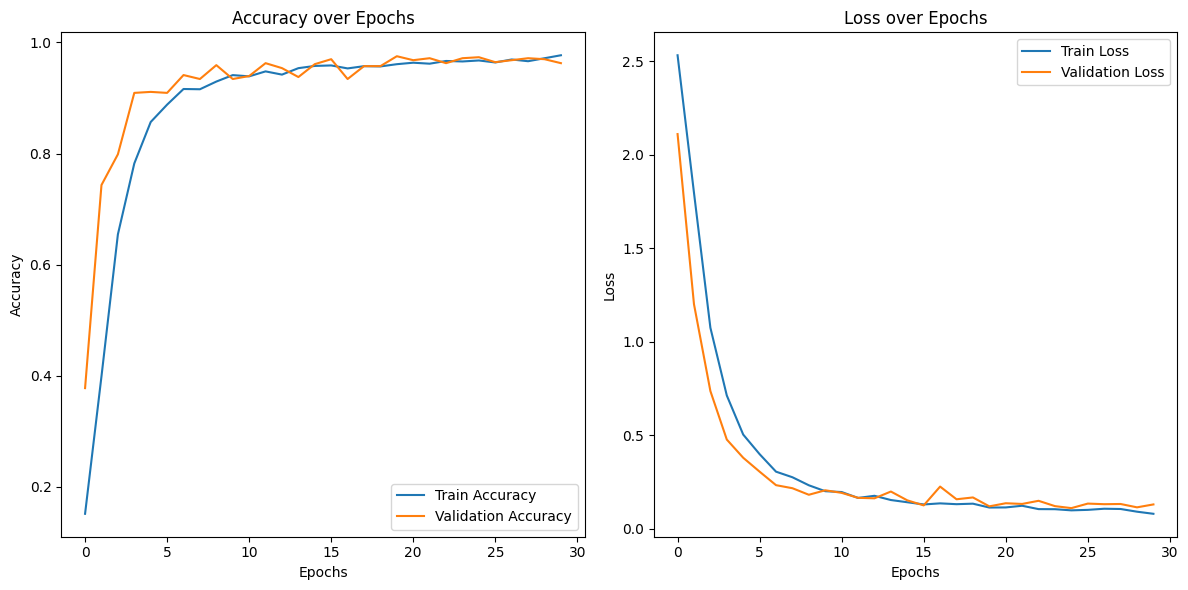

In [88]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [89]:
# Function to predict emotion for a new audio file
def predict_emotion(file_path):
    # Extract features from the audio file
    features = extract_features(file_path)
    
    # Reshape to fit RNN input (1 sample, 1 time step, num_features)
    features = features.reshape(1, 1, features.shape[0])
    
    # Predict the emotion
    prediction = model.predict(features)
    
    # Map prediction to emotion
    emotion_dict_reverse = {
        0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
        4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
        8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
        12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
    }
    
    # Get the predicted class index
    predicted_class = np.argmax(prediction)
    
    # Return the emotion label
    return emotion_dict_reverse[predicted_class]

# Example usage
file_path = "D://PYTHON//SPEECH//Tess//OAF_Fear//OAF_burn_fear.wav"
predicted_emotion = predict_emotion(file_path)
print(f'Predicted emotion: {predicted_emotion}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
Predicted emotion: OAF_Fear


In [90]:
model.save("RNN.h5")

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


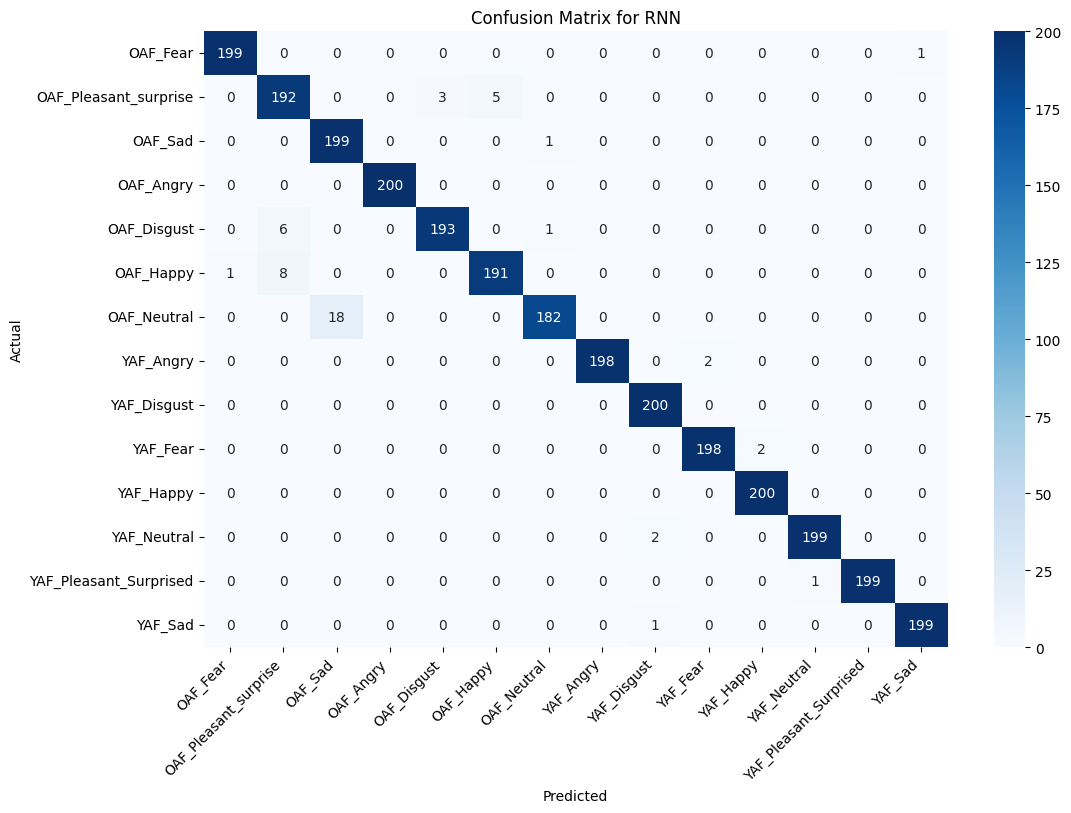

In [91]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

# Function to extract features from audio file
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel = np.mean(mel, axis=1)
    return np.concatenate((mfcc, chroma, mel), axis=0)

# Function to load all audio files and extract features
def load_data(data_path):
    features = []
    labels = []
    emotion_dict = {
        'OAF_Fear': 0, 'OAF_Pleasant_surprise': 1, 'OAF_Sad': 2,
        'OAF_Angry': 3, 'OAF_Disgust': 4, 'OAF_Happy': 5, 'OAF_Neutral': 6,
        'YAF_Angry': 7, 'YAF_Disgust': 8, 'YAF_Fear': 9, 'YAF_Happy': 10,
        'YAF_Neutral': 11, 'YAF_Pleasant_Surprised': 12, 'YAF_Sad': 13
    }
    
    for emotion in emotion_dict.keys():
        emotion_folder = os.path.join(data_path, emotion)
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file_name)
                features.append(extract_features(file_path))
                labels.append(emotion_dict[emotion])
    
    return np.array(features), np.array(labels)

# Function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for RNN")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

# Set the path to the test folder of your dataset
test_data_path = r"D:\PYTHON\SPEECH\Tess\Test"
X_test, y_test = load_data(test_data_path)

# Preprocess labels (one-hot encoding)
y_test = to_categorical(y_test, num_classes=14)

# Reshape data for LSTM (samples, time steps, features)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Load the trained model (if not already in memory)
model = load_model('RNN.h5')  # Use the correct model path

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Class names (updated to your emotion_dict keys)
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_Angry', 'OAF_Disgust', 'OAF_Happy', 
    'OAF_Neutral', 'YAF_Angry', 'YAF_Disgust', 'YAF_Fear', 'YAF_Happy', 'YAF_Neutral', 
    'YAF_Pleasant_Surprised', 'YAF_Sad'
]

# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)


In [92]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test accuracy and test loss
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0855
Test Accuracy: 0.9814
Test Loss: 0.0633


In [93]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from keras.models import load_model  # Assuming you're using Keras for the model

# Define class names as provided
class_names = [
    'OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral',
    'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad'
]

# Load your trained model (replace 'cnn-lstm.h5' with your model file)
model = load_model('RNN.h5')

# Prepare your test data (replace with your actual test data)
# Example: X_test, y_test = your_data_loading_function()

# Predict using the trained model
y_pred = model.predict(X_test)

# If it's a multi-class classification, use np.argmax to get the predicted class index
y_pred = np.argmax(y_pred, axis=1)  # If it's a softmax output for multiclass classification

# If y_test is one-hot encoded, convert it to class indices as well
# This step ensures that both y_test and y_pred are in the same format
y_test = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and f1 score for each class
precision = precision_score(y_test, y_pred, average=None)  # Precision for each class
recall = recall_score(y_test, y_pred, average=None)        # Recall for each class
f1 = f1_score(y_test, y_pred, average=None)                # F1 score for each class

# Calculate overall precision, recall, and F1 score (macro average)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.4f}")

# Print precision, recall, and f1 score for each class
for i, class_name in enumerate(class_names):
    print(f"\nMetrics for {class_name}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1 score: {f1[i]:.4f}")

# Print overall (macro average) precision, recall, and F1 score
print("\nOverall (macro average) metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 score (Macro): {f1_macro:.4f}")


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.9814

Metrics for OAF_Fear:
Precision: 0.9950
Recall: 0.9950
F1 score: 0.9950

Metrics for OAF_Pleasant_surprise:
Precision: 0.9320
Recall: 0.9600
F1 score: 0.9458

Metrics for OAF_Sad:
Precision: 0.9171
Recall: 0.9950
F1 score: 0.9544

Metrics for OAF_angry:
Precision: 1.0000
Recall: 1.0000
F1 score: 1.0000

Metrics for OAF_disgust:
Precision: 0.9847
Recall: 0.9650
F1 score: 0.9747

Metrics for OAF_happy:
Precision: 0.9745
Recall: 0.9550
F1 score: 0.9646

Metrics for OAF_neutral:
Precision: 0.9891
Recall: 0.9100
F1 score: 0.9479

Metrics for YAF_angry:
Precision: 1.0000
Recall: 0.9900
F1 score: 0.9950

Metrics for YAF_disgust:
Precision: 0.9852
Recall: 1.0000
F1 score: 0.9926

Metrics for YAF_fear:
Precision: 0.9900
Recall: 0.9900
F1 score: 0.9900

Metrics for YAF_happy:
Precision: 0.9901
Recall: 1.0000
F1 score: 0.9950

Metrics for YAF_neutral:
Precision: 0.9950
Recall: 0.9900
F1 score: 0.9925

Metrics for YAF_pleasant_surprised:
Pre